# Description

This notebook cotains a model to predict the daily average load for the next 5 weeks in a single step. The features are detailed in days.

# Load Libs

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error

import pendulum

In [2]:
tf.config.list_physical_devices()

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]

In [3]:
regiao = 'SUDESTE'
SEED = 42

batch_size = 32
# number of week to be predicted
predict_weeks = 5
# target days to sum into weeks
target_period = 7*predict_weeks
# number of weeks in the window
n_weeks_ws = 5
# window size in days for each row
window_size = 7*n_weeks_ws

filepath = 'Models/Model_v2.h5'


np.random.seed(SEED)
tf.random.set_seed(SEED)

# períodograma; 
autocorrelação total e parcial

progressive time-series validation.

regressão linear de baseline

prediction = []
for window in train_dataset:
    for step in range(0,5):
        forecast = model.forecast(window[-window_size:])
        window = tf.concat(values=[window, forecast], axis=-1)
        window_pred.append(forecast)
    prediction.append(window_pred)

# Load data

In [4]:
def load_data(start=2009, end=2021):
    """load data from ONS"""

    cwd_dir = os.getcwd()
     
    first_year = os.path.join(cwd_dir, f'Data/CARGA_ENERGIA_{start}.csv')

    df_20XX = pd.read_csv(first_year, 
                        sep=';', 
                        parse_dates=['din_instante'])

    for x in range(start+1,end+1):
        df_20XX = pd.concat(objs = (df_20XX,
                                    pd.read_csv(os.path.join(cwd_dir, 
                                                            f'Data/CARGA_ENERGIA_{x}.csv'), 
                            sep=';', 
                            parse_dates=['din_instante'])))
    return df_20XX.reset_index(drop=True)

In [5]:
df_20XX = load_data(start=2009, end=2022)
df_20XX.tail()

,id_subsistema,nom_subsistema,din_instante,val_cargaenergiamwmed
19292,SE,SUDESTE,2022-03-16,45707.771625
19293,N,NORTE,2022-03-17,5824.884833
19294,NE,NORDESTE,2022-03-17,11939.179500
19295,S,SUL,2022-03-17,13333.546958
19296,SE,SUDESTE,2022-03-17,46527.870500


# Preprocess data

In [6]:
class Preprocessor(BaseEstimator, TransformerMixin):

  def __init__(self, regiao):
    self.regiao = regiao
    self.missing_days = []
    pass


  def fit(self, df:pd.DataFrame,):
    """ Learns the missing days """
    df = df.copy()
    # filter by subsystem
    df = self.filter_subsystem(df, regiao = self.regiao)
    # saves missing days in a variable called missing_days 
    self.missing_days = df[pd.isna(df.val_cargaenergiamwmed)].din_instante
    return self 


  def transform(self, df:pd.DataFrame):
    """ Applies transformations """
    df = df.copy()
    df = self.filter_subsystem(df, regiao = self.regiao)  # filter by subsystem
    df = self.impute_nan(df)                              # impute/drop NaN values
    df = self.go_to_friday(df)        # starts the dataset at a friday - the operative week 
    df = self.parse_dates(df)         # create columns parsing the data
    df = self.drop_incomplete_week(df)    # drop last rows so to have full weeks
    self.check_dq(df)                   # prints the NaN values for loadand missing days
    return df


  def filter_subsystem(self, df:pd.DataFrame, regiao:str):
    """ filter data by subsystem and reset index """
    df = df.copy()
    # try and except so it doesn't crash if it's applied to an already treated dataset
    try:
      df = df[df['nom_subsistema']==regiao].reset_index().drop('index',axis=1).copy()
    except:
      pass
    # dropa columns about subsystem
    df.drop(labels=['nom_subsistema','id_subsistema'], inplace=True, axis=1,errors='ignore')
    # reset index of concatenated datasets
    df.reset_index(inplace=True,drop=True)
    return df


  def impute_nan(self, df):
    """ impute the 12 NaN values """
    df = df.copy()
    time_col = 'din_instante'
    load_col = 'val_cargaenergiamwmed'
    if len(self.missing_days) != 0:
      # If the NaN weren't already dealt with:
      if df[df[time_col] == self.missing_days.iloc[0]].val_cargaenergiamwmed.isna().item():
        # impute missing day '2013-12-01' with the load from the day before
        df.at[(df[df.din_instante == self.missing_days.iloc[0]].index.item()), 
              load_col] = df[load_col].iloc[self.missing_days.index[0] - 1]
        # impute missing day '2014-02-01' with the load from the day before
        df.at[(df[df.din_instante == self.missing_days.iloc[1]].index.item()), 
              load_col] = df[load_col].iloc[self.missing_days.index[1] - 1]
        
        # Impute 2015-04-09
        # variation between april 9 (wednesday) and april 10 (thursday) of 2014
        var2014 = df[df['din_instante'] == r'2014-04-10'].val_cargaenergiamwmed.item() /  df[df['din_instante'] == r'2014-04-09'].val_cargaenergiamwmed.item()
        # index of 2015-04-09, the missing day in 2015
        index_2015 = df[df['din_instante'] == r'2015-04-09'].index.item()
        # replace the missing day of 2015 with the day before * variation between same days in 2014
        df.loc[index_2015, 'val_cargaenergiamwmed'] = df[df['din_instante'] == r'2015-04-08'].val_cargaenergiamwmed.item()*var2014

        # Impute missing days from 2016-04-05 to 2016-04-13
        # list of daily variations between 2015-04-07 and 2015-04-16  
        var_2015 =[]
        for dia in range(7,16):
            var_2015.append(df[df['din_instante'] == r'2015-04-{:0>2d}'.format(dia)].val_cargaenergiamwmed.item() / 
                        df[df['din_instante'] == r'2015-04-{:0>2d}'.format(dia-1)].val_cargaenergiamwmed.item())
        # index of 2016-04-05, the begining of the 9 missing days in 2016
        index_2016 = df[df['din_instante'] == r'2016-04-05'].index.item()

        for x in range(0,9):
            df.loc[index_2016 + x,'val_cargaenergiamwmed'] = df[df['din_instante'] == r'2015-04-{:0>2d}'.format(x+7)].val_cargaenergiamwmed.item()*var_2015[x]
    return df


  def go_to_friday(self,df): 
    """ go next friday = begining of the operative week"""
    df = df.copy()
    # first day in dataset
    date_time = df['din_instante'].iloc[0]
    # check if the dataset starts on a friday 
    if date_time.day_name() != 'Friday':
      # today
      dt = pendulum.datetime(date_time.year,date_time.month, date_time.day)
      # next friday - begins the operative week
      next_friday = dt.next(pendulum.FRIDAY).strftime('%Y-%m-%d')
      # df starts with the begin of operative week
      df = df[df['din_instante'] >= next_friday].reset_index(drop=True).copy()
    
    return df


  def parse_dates(self, df):
    """ parse date into year, month, month day and week day  """
    df = df.copy()
    
    df['semana'] = (df.index)//7
    df['dia semana'] = df['din_instante'].dt.day_name()
    df['dia mes'] = df['din_instante'].dt.day
    df['Mes'] = df['din_instante'].dt.month
    df['ano'] = df['din_instante'].dt.year
    return df


  def drop_incomplete_week(self,df):
    """ drop incomplete week at the bottom of the dataset """
    for i in range(6):
      if df['dia semana'].tail(1).item() == 'Thursday':
        break
      else:
        df.drop(labels=df.tail(1).index, axis=0, inplace=True)

    return df
  

  def check_dq(self,df):
    # check for NaN values
    nan_data = df[pd.isna(df.val_cargaenergiamwmed)].din_instante
    if len(nan_data) != 0:
        print("NaN values: \n")
        print(nan_data)
    else:
        print('No missing NaN.')
    
    # check for missing days in the series
    missing_days = pd.date_range(start = df.din_instante.iloc[0], 
                                 end= df.din_instante.iloc[-1],
                                 freq='D').difference(df.din_instante)
    if len(missing_days) != 0:
        print("\nMissing days in the series:")
        print(missing_days)
    else:
        print("\nNo missing days in the series")

  def split_time(self, df, val_start=0.7, test_start=0.9, folds=3):
    """ Split dataset into train, validation and teste data

    Args:
        df (pd.DataFrame): data
        val_start (float, optional): the proportion of the dataset where starts validation data. Defaults to 0.7.
        test_start (float, optional): the proportion of the dataset where starts test data. Defaults to 0.9.
        regiao (str, optional): Subsystem to filter data. Defaults to "SUDESTE".

    Returns:
        pd.DataFrame: train data, validation data and test data dataframes 
    """
    df = df.copy()
    # index of end of training dataset, start of validation dataset
    split_val = int(len(df)*val_start)
    # make sure we split the dataset on a friday - first day of the operative week
    for x in range(0,7):
        # Check if the last day is friday, then the day before, then before...
        if df.loc[split_val-x,'dia semana'] == 'Friday':
            # when we find the friday before the split, we update the split index
            split_val = split_val - x
            break
    # index of end of validation dataset, start of test dataset
    split_test = int(len(df)*test_start)
    # make sure we split the dataset on a friday - first day of the operative week
    for i in range(0,7):
      # Check if the last day is friday, then the day before, then before...
        if df.loc[split_test-i,'dia semana'] == 'Friday':
            # when we find the friday before the split, we update the split index
            split_test = split_test - i
            break    
    # split datasets into train, validation and test  3 folds
    if folds == 3:
      train_df = df[:split_val]
      val_df = df[split_val:split_test]
      test_df = df[split_test:]
      print(f"First day of train_df: {train_df.din_instante.iloc[0]}")
      print(f"First day of val_df: {val_df.din_instante.iloc[0]}")
      print(f"First day of test_df: {test_df.din_instante.iloc[0]}")
      return train_df, val_df, test_df

    # split datasets into train and test - 2 folds
    if folds == 2:
      train_df = df[:split_val]
      val_df = df[split_val:]
      print(f"First day of train_df: {train_df.din_instante.iloc[0]}")
      print(f"First day of val_df: {val_df.din_instante.iloc[0]}")
      return train_df, val_df


In [7]:
pp = Preprocessor(regiao='SUDESTE')
df = pp.fit_transform(df_20XX)

No missing NaN.

No missing days in the series


# Split Data

In [8]:
train_df, val_df, test_df = pp.split_time(df=df,
                                            folds = 3,
                                            val_start=0.7, 
                                            test_start=0.9)

First day of train_df: 2009-01-02 00:00:00
First day of val_df: 2018-03-30 00:00:00
First day of test_df: 2020-11-20 00:00:00


# Target

In [108]:
def create_target_df(df, baseline_size=1):
  """ returns a dataframe with target values and baseline"""
  # average daily load by operative week
  df_target = pd.DataFrame(data=df.groupby(by=['semana'])['val_cargaenergiamwmed'].mean())
  # start day of each operative week
  df_target.columns = ['Semana 1']
  df_target['Semana 2'] = df_target['Semana 1'].shift(-1)
  df_target['Semana 3'] = df_target['Semana 1'].shift(-2)
  df_target['Semana 4'] = df_target['Semana 1'].shift(-3)
  df_target['Semana 5'] = df_target['Semana 1'].shift(-4)
  # defines the first day of Semana 1
  df_target['Data'] = df.groupby(by=['semana'])['din_instante'].min()
  df_target['dia semana'] = df.groupby(by=['semana'])['dia semana'].min()
  df_target['Resíduo'] = df_target['Semana 2']  - df_target['Semana 1']
  df_target['Média Móvel'] = df_target['Semana 1'].shift(1).rolling(baseline_size).mean()
  return df_target

In [109]:
df_target = create_target_df(df, baseline_size=5)
df_target.tail(6)

,Semana 1,Semana 2,Semana 3,Semana 4,Semana 5,Data,dia semana,Resíduo,Média Móvel
semana,,,,,,,,,
683,41838.713446,42354.806815,42908.934060,43796.079827,45429.410685,2022-02-04,Friday,516.093369,41195.864911
684,42354.806815,42908.934060,43796.079827,45429.410685,44590.574107,2022-02-11,Friday,554.127244,41920.741824
685,42908.934060,43796.079827,45429.410685,44590.574107,NaN,2022-02-18,Friday,887.145768,42568.066937
686,43796.079827,45429.410685,44590.574107,NaN,NaN,2022-02-25,Friday,1633.330857,42662.702388
687,45429.410685,44590.574107,NaN,NaN,NaN,2022-03-04,Friday,-838.836577,42535.193224
688,44590.574107,NaN,NaN,NaN,NaN,2022-03-11,Friday,NaN,43265.588967


# Process Data 

In [10]:
class Window_Generator(BaseEstimator):
    
    def __init__(self, target_period, window_size, batch_size,shuffle_buffer,
                 regiao = regiao, SEED=SEED, how = 'dia para semana'):
        self.target_period = target_period
        self.window_size = window_size
        self.batch_size = batch_size
        self.shuffle_buffer = shuffle_buffer
        self.regiao = regiao
        self.SEED = SEED
        self.how = how
        assert self.how in ['dia para semana', 'sazonalidade anual']
        assert self.window_size % 7 == 0, "window_size deve ser divisível de 7"
    pass
    
    def generate_data_week(self, df):
        """Generate a list with the same index as the window features with the first
            day of the first week of the target
        Returns:
            data_week: first day of the first target week
        """
        df = df.copy()
        # if df['din_instante'].iloc[0].day_name() != 'Friday':
        #     # get next friday - begins the operative week
        #     df = Preprocessor(regiao=self.regiao).go_to_friday(df)
        # groupby object by week and then by day
        df_grouped = df[self.window_size:].groupby(by=['semana'])['din_instante']
        # get first day of each week and  removes the last 4 rows 
        # because we want to save the first day of the first target week
        # so we drop the last target 4 weeks 
        return df_grouped.min()[:-4]
    
    def map_data(self, dataset):
        """Defines how the data will be processed into features and target.
        If self.how = 'dia para semana', the features will be in daily load of window_size lenght.
        If self.how = 'sazonalidade anual', the features will be the last 4 weeks and the same week from last year.

        Args:
            dataset (tf.data.Dataset): windowed dataset

        Returns:
            tf.data.Dataset: dataset processed into features and targets
        """
        if self.how == 'dia para semana':
            dataset = dataset.map(lambda window:(window[:-self.target_period],   #features
                                        [tf.math.reduce_sum(window[-35:-28])/7, # first target week
                                        tf.math.reduce_sum(window[-28:-21])/7, # second target week
                                        tf.math.reduce_sum(window[-21:-14])/7, # third target week
                                        tf.math.reduce_sum(window[-14:-7])/7,  # fourth target week
                                        tf.math.reduce_sum(window[-7:])/7]      # fifith target week
                                                )
                                 )
        
        if self.how == 'sazonalidade anual':
            assert self.window_size >= 365, "window size menor que 365 dias, não é possível usar how = 'sazonalidade anual'"

            dataset = dataset.map(lambda window:(tf.concat(values=[window[-364-self.target_period:-357-self.target_period],
                                                                   window[-14-self.target_period:-self.target_period]],
                                                            axis=-1),   #features
                                        [tf.math.reduce_sum(window[-35:-28])/7, # first target week
                                        tf.math.reduce_sum(window[-28:-21])/7, # second target week
                                        tf.math.reduce_sum(window[-21:-14])/7, # third target week
                                        tf.math.reduce_sum(window[-14:-7])/7,  # fourth target week
                                        tf.math.reduce_sum(window[-7:])/7]      # fifith target week
                                                )
                                 )

        return dataset

    def transform(self, df, shuffle=True):
        """Transform a preprocessed dataframe in a windowed dataset
        Returns:
            dataset: a windowed tensorflow.dataset with window_size timesteps for features
                     and the average daily load for the next five weeks as targets
        """
        df = df.copy()
        data_week = self.generate_data_week(df)

        series = df['val_cargaenergiamwmed']
        # generate tf.dataset
        dataset = tf.data.Dataset.from_tensor_slices(series)
        
        # create windows 
        dataset = dataset.window(self.window_size + self.target_period, shift=7, drop_remainder=True)
        # make sure every window is the same size / clip NaN at the end
        dataset = dataset.flat_map(lambda window: window.batch(self.window_size + self.target_period))
        if shuffle:
            # randomly shuffles the windows instances in the dataset 
            dataset = dataset.shuffle(self.shuffle_buffer,seed=self.SEED)
        # separates features and target and take the average of the target days by week
        dataset = self.map_data(dataset)

        # batch and prefetch
        dataset = dataset.batch(batch_size).prefetch(1)
        return dataset, data_week

In [11]:
wd = Window_Generator(batch_size = batch_size, 
                     window_size = 5*7,
                     shuffle_buffer = 20, 
                     target_period = target_period, 
                     how = 'dia para semana',
                     SEED = SEED)



# dataset to training
train_dataset, train_data_week = wd.transform(df = train_df, shuffle=True)

# dataset for performance evaluation
train_pred_dataset, train_pred_data_week = wd.transform(df = train_df, shuffle=False)
val_dataset, val_data_week = wd.transform(df = val_df, shuffle=False)
test_dataset, test_data_week = wd.transform(df = test_df, shuffle=False)

## Check data processing:

In [12]:
for x1, y1 in  train_pred_dataset:
    x2=x1
x2[-1]

<tf.Tensor: shape=(35,), dtype=float64, numpy=
array([43622.99158333, 39452.90891667, 36185.29416667, 43087.81983333,
       44249.764625  , 44329.28583333, 43445.88816667, 42692.44254167,
       38043.358375  , 34781.619     , 41570.37470833, 40541.29983333,
       39127.14816667, 39501.93791667, 39790.78179167, 36699.03270833,
       32710.114     , 38013.91458333, 38621.50220833, 39425.87529167,
       40641.39929167, 41638.36341667, 37707.234625  , 34259.398875  ,
       37141.292625  , 36651.31425   , 39142.85125   , 39368.94541667,
       40181.16820833, 37522.88608333, 33821.85116667, 39850.44441667,
       41204.62004167, 41981.18370833, 41703.41545833])>

In [13]:
df[df['val_cargaenergiamwmed'] == x2[-1][0]]

,din_instante,val_cargaenergiamwmed,semana,dia semana,dia mes,Mes,ano
3304,2018-01-19,43622.991583,472,Friday,19,1,2018


In [14]:
df[df['val_cargaenergiamwmed'] == x2[-1][-1]]

,din_instante,val_cargaenergiamwmed,semana,dia semana,dia mes,Mes,ano
3338,2018-02-22,41703.415458,476,Thursday,22,2,2018


In [15]:
c=0
for x,y in train_pred_dataset:
  #print('x=', x)
  #print('y=', y)
  c +=1
  print(x.shape,y.shape)
  break
#print(c*batch_size)

(32, 35) (32, 5)


# Baseline

In [78]:
def baseline_metrics(df_target=df_target, date_list=date_list):
    # metrics for baseline model
    metrics_baseline = pd.DataFrame(index = ['train', 'val', 'test'], 
                        data = 

            {'MAE' : [tf.keras.metrics.mean_absolute_error(
            # target
            df_target[f'Semana 1'].loc[np.array(date_list[x].index)],
            # baseline (week before)
            df_target[f'Média Móvel'].loc[np.array(date_list[x].index)]).numpy()
            for x in range(0,3)],
            
            'MAPE' : [tf.keras.metrics.mape(
            # target
            df_target[f'Semana 1'].loc[np.array(date_list[x].index)],
            # baseline (week before)
            df_target[f'Média Móvel'].loc[np.array(date_list[x].index)]).numpy()
            for x in range(0,3)],

            'MSE' : [tf.keras.metrics.mse(
             # target
            df_target[f'Semana 1'].loc[np.array(date_list[x].index)],
            # baseline (week before)
            df_target[f'Média Móvel'].loc[np.array(date_list[x].index)]).numpy()
            for x in range(0,3)],

            'MSLE' : [tf.keras.metrics.msle(
            # target
            df_target[f'Semana 1'].loc[np.array(date_list[x].index)],
            # baseline (week before)
            df_target[f'Média Móvel'].loc[np.array(date_list[x].index)]).numpy()
            for x in range(0,3)],

            'RMSE' : [tf.keras.metrics.RootMeanSquaredError().update_state(
                        # target
            df_target[f'Semana 1'].loc[np.array(date_list[x].index)],
            # baseline (week before)
            df_target[f'Média Móvel'].loc[np.array(date_list[x].index)]).numpy()
            for x in range(0,3)]
            })
    return metrics_baseline

In [16]:
class Baseline(tf.keras.Model):
  
  """ If how = "last week", pass the last week five times as prediction
      for the next five weeks. 
      IF how = "five weeks" past the last 5 weeks of the input window 
      as predictions for the next five 
  """
  
  def __init__(self,how):
    super().__init__()
    self.how = how
    pass

  
  def call(self, inputs):

    # last five weeks as prediction for the next five, respectivamente
    if self.how == 'five weeks':
      result =[tf.math.reduce_sum(inputs[0,-35:-28])/7, # first target week - five weeks before
              tf.math.reduce_sum(inputs[0,-28:-21])/7, # second target week - five weeks before
              tf.math.reduce_sum(inputs[0,-21:-14])/7, # third target week - five weeks before
              tf.math.reduce_sum(inputs[0,-14:-7])/7,  # fourth target week - five weeks before
              tf.math.reduce_sum(inputs[0,-7:])/7    # fifith target week - five weeks before
              ]     
    
    # last week five times as prediction for the next five weeks  
    elif self.how == 'last week':
      result=[tf.math.reduce_sum(inputs[0,-7:])/7, # first target week - five weeks before
              tf.math.reduce_sum(inputs[0,-7:])/7, # second target week - five weeks before
              tf.math.reduce_sum(inputs[0,-7:])/7, # third target week - five weeks before
              tf.math.reduce_sum(inputs[0,-7:])/7,  # fourth target week - five weeks before
              tf.math.reduce_sum(inputs[0,-7:])/7    # fifith target week - five weeks before
              ]     
              
    return result

In [17]:
base_wd = Window_Generator(batch_size = batch_size, 
                     window_size = 5*7,
                     shuffle_buffer = 20, 
                     target_period = target_period, 
                     how = 'dia para semana',
                     SEED = SEED)

# dataset to training
base_train_dataset, _ = base_wd.transform(df = train_df, shuffle=False)

# dataset for performance evaluation
base_val_dataset, _ = base_wd.transform(df = val_df, shuffle=False)
base_test_dataset, _ = base_wd.transform(df = test_df, shuffle=False)

In [18]:
c=0
for x,y in base_train_dataset:
  #print('x=', x)
  #print('y=', y)
  c +=1
  print(x.shape,y.shape)
  break
#print(c*batch_size)

(32, 35) (32, 5)


In [19]:
base_model = Baseline(how='five weeks')
# compile
base_model.compile(loss=tf.losses.MeanSquaredError(),
                metrics=[tf.metrics.MeanAbsoluteError(),
                        tf.metrics.MeanAbsolutePercentageError(),
                        tf.keras.metrics.RootMeanSquaredError()
                        ])

train_performance = base_model.evaluate(base_train_dataset, verbose=0)
val_performance = base_model.evaluate(base_val_dataset, verbose=0)
test_performance = base_model.evaluate(base_test_dataset, verbose=0)

semana1_base = pd.DataFrame(data = {'MAE': [train_performance[6],val_performance[6],test_performance[6]], 
                                    'MAPE': [train_performance[7],val_performance[7],test_performance[7]],
                                    'MSE': [train_performance[1],val_performance[1],test_performance[1]],
                                    "RMSE": [train_performance[8],val_performance[8],test_performance[8]]},
                            index=['train', 'val' , 'test']
                            )
print('\n Metricas da baseline para a semana 1')
semana1_base



 Metricas da baseline para a semana 1


,MAE,MAPE,MSE,RMSE
train,2615.410400,7.446875,10240475.0,3200.074463
val,3722.821289,10.527076,20585946.0,4537.173828
test,2920.989014,7.123868,13294213.0,3646.123047


In [20]:
semana5_base = pd.DataFrame(data = {'MAE': [train_performance[-3],val_performance[-3],test_performance[-3]], 
                                    'MAPE': [train_performance[-2],val_performance[-2],test_performance[-2]],
                                    'MSE': [train_performance[2],val_performance[2],test_performance[2]],
                                    "RMSE": [train_performance[-1],val_performance[-1],test_performance[-1]]},
                            index=['train', 'val' , 'test'])

print("Métricas da baseline para semana 5")
semana5_base                            

Métricas da baseline para semana 5


,MAE,MAPE,MSE,RMSE
train,2521.541260,7.137256,10948074.0,3116.693848
val,2998.210693,8.301979,14668727.0,3589.189941
test,3003.958008,7.466480,13873282.0,3577.017822


# train model

In [21]:
def compile_and_fit(model, data, val_data, epochs,optimizer,
                    filepath=filepath, patience=4):
  # early stopping callback
  early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss',
                                                    patience=patience,
                                                    mode='min')
  # checkpoint callback
  checkpoint = tf.keras.callbacks.ModelCheckpoint(filepath = filepath, monitor = 'loss', 
                               verbose = 1, save_best_only = True, mode = 'min')
  
  # compile
  model.compile(loss=tf.losses.MeanSquaredError(),
                optimizer=optimizer,
                metrics=[tf.metrics.MeanAbsoluteError(),
                         tf.metrics.MeanAbsolutePercentageError(),
                         tf.keras.metrics.RootMeanSquaredError()])
  # fit data
  history = model.fit(data, epochs=epochs, verbose=0,
                      validation_data= val_data,
                      callbacks=[early_stopping # , checkpoint
                    ])
  return history

In [79]:
# LSTM
model = tf.keras.models.Sequential([
    tf.keras.layers.Lambda(lambda x: tf.expand_dims(x, axis = -1), input_shape=[None]),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.LSTM(100, return_sequences=False, activation ='tanh'),
    tf.keras.layers.Dense(5),
    tf.keras.layers.Lambda(lambda x: x * 10000.0)
    ])


history = compile_and_fit(model, epochs = 100, 
                          data=train_dataset, 
                          val_data = val_dataset,
                          optimizer = tf.optimizers.Adam(learning_rate=0.001),
                          patience = 50,
                          filepath = filepath)

# make predictions
train_pred = model.predict(train_pred_dataset)
val_pred = model.predict(val_dataset)
test_pred = model.predict(test_dataset)

date_list = [train_pred_data_week,val_data_week,test_data_week]
pred_list = [train_pred, val_pred, test_pred]

# Evaluate

In [80]:
def learning_curves(history, skip):
  # starting epoch to plot
  skip = 20

  fig,ax = plt.subplots(figsize=(30,6), nrows=1, ncols=3)
  metrics_list = ['loss',
                  'val_loss',
                  'mean_absolute_error', 
                  'val_mean_absolute_error',
                  'root_mean_squared_error',
                  'val_root_mean_squared_error'
                  ]

  for i, metric in enumerate(metrics_list):
    if i<=1:
      ax1 =  ax.ravel()[0]
    elif i>1 and i<=3:
      ax1 =  ax.ravel()[1]
    else:
      ax1= ax.ravel()[2]
    sns.lineplot(x = range(skip,len(history.history[metric])),
                y = history.history[metric][skip:],
                ax = ax1)


  ax.ravel()[0].set_title("Learning Curve: MSE - loss")
  ax.ravel()[0].legend(labels=['Treino', 'Validação'])
  ax.ravel()[1].set_title("Learning Curve: MAE")
  ax.ravel()[1].legend(labels=['Treino', 'Validação'])
  ax.ravel()[2].set_title("Learning Curve: RMSE")
  ax.ravel()[2].legend(labels=['Treino', 'Validação'])

  plt.show()

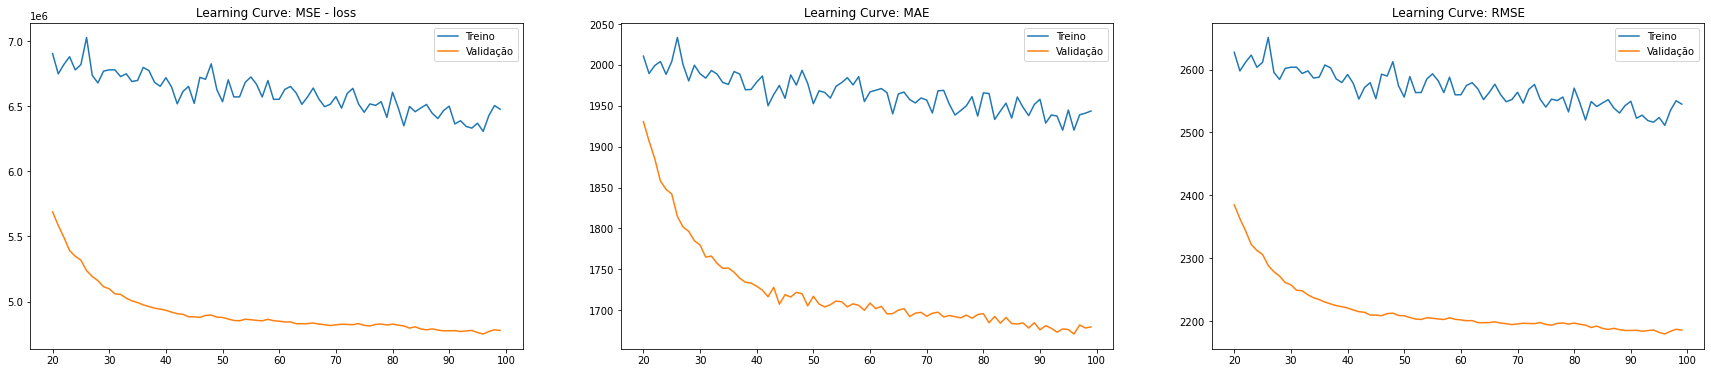

In [81]:
learning_curves(history=history, skip=20)

In [82]:
# load weights from the epoch with best validation loss in training
#model.load_weights(filepath)


# evaluate performance
print("Train dataset 5 weeks evaluation:")
model.evaluate(train_dataset)
print("Val dataset 5 weeks evaluation:")
model.evaluate(val_dataset)
print("test dataset 5 weeks evaluation:")
model.evaluate(test_dataset)

Train dataset 5 weeks evaluation:
15/15 [==============================] - 0s 7ms/step - loss: 3933742.0000 - mean_absolute_error: 1571.5468 - mean_absolute_percentage_error: 4.5895 - root_mean_squared_error: 1983.3663
Val dataset 5 weeks evaluation:
5/5 [==============================] - 0s 9ms/step - loss: 4777639.0000 - mean_absolute_error: 1679.4991 - mean_absolute_percentage_error: 4.6025 - root_mean_squared_error: 2185.7810
test dataset 5 weeks evaluation:
2/2 [==============================] - 0s 17ms/step - loss: 7473770.5000 - mean_absolute_error: 2085.2881 - mean_absolute_percentage_error: 5.0754 - root_mean_squared_error: 2733.8198


[7473770.5, 2085.2880859375, 5.075352191925049, 2733.81982421875]

In [106]:
def plot_pred(date_list, pred_list, df_target=df_target, baseline=False):
    
    colors = ['orange', 'green', 'purple']
    _,ax=plt.subplots(figsize=(20,35), ncols=1, nrows=5)
    extra = plt.Rectangle((0, 0), 0, 0, fc="none", fill=False, ec='none', linewidth=0)

    if baseline == True:
        sns.lineplot(x = df_target['Data'],
                y = df_target['Média Móvel'], 
                ax=np.ravel(ax)[0],
                color='black')


    for x in range(0,5):
        # plot measured data
        sns.lineplot(x = df_target['Data'], 
                    y = df_target[f'Semana {x+1}'], 
                    ax=np.ravel(ax)[x], 
                    color = 'teal')

        # plot predicted data
        for date,pred,color in zip(date_list, 
                                pred_list,
                                colors): 
            sns.lineplot(x = date[:].shift(x),
                        y = pred[:,x], 
                        ax=np.ravel(ax)[x],
                        color=color)
                        

        np.ravel(ax)[x].set_title(f'Carga real vs Predição em todo o período - Semana {x+1}')
        # np.ravel(ax)[x].legend(['Real','Previsão no treino','Previsão na validação','Previsão no teste'], loc='upper left')

        
        scores = (r"MAE Train ={:.0f}"+'\n'+r"MAE val ={:.0f}"+"\n"+r"MAE test ={:.0f}").format(
                tf.keras.metrics.mean_absolute_error(df_target[f'Semana {x+1}'].loc[np.array(date_list[0].index)],
                                                    train_pred[:,x]).numpy(),
                tf.keras.metrics.mean_absolute_error(df_target[f'Semana {x+1}'].loc[np.array(date_list[1].index)],
                                                    val_pred[:,x]).numpy(),
                tf.keras.metrics.mean_absolute_error(df_target[f'Semana {x+1}'].loc[np.array(date_list[2].index)],
                                                    test_pred[:,x]).numpy() 
                                                                                                )
        np.ravel(ax)[x].legend([extra], [scores], loc='lower right')
    plt.show()

In [91]:
metrics_baseline = baseline_metrics(df_target)
metrics_baseline

,MAE,MAPE,MSE,MSLE,RMSE
train,1066.784732,3.024224,2.046050e+06,0.001619,473.0
val,1320.364192,3.582680,3.141191e+06,0.002227,129.0
test,1258.543661,3.184702,2.846486e+06,0.001803,60.0


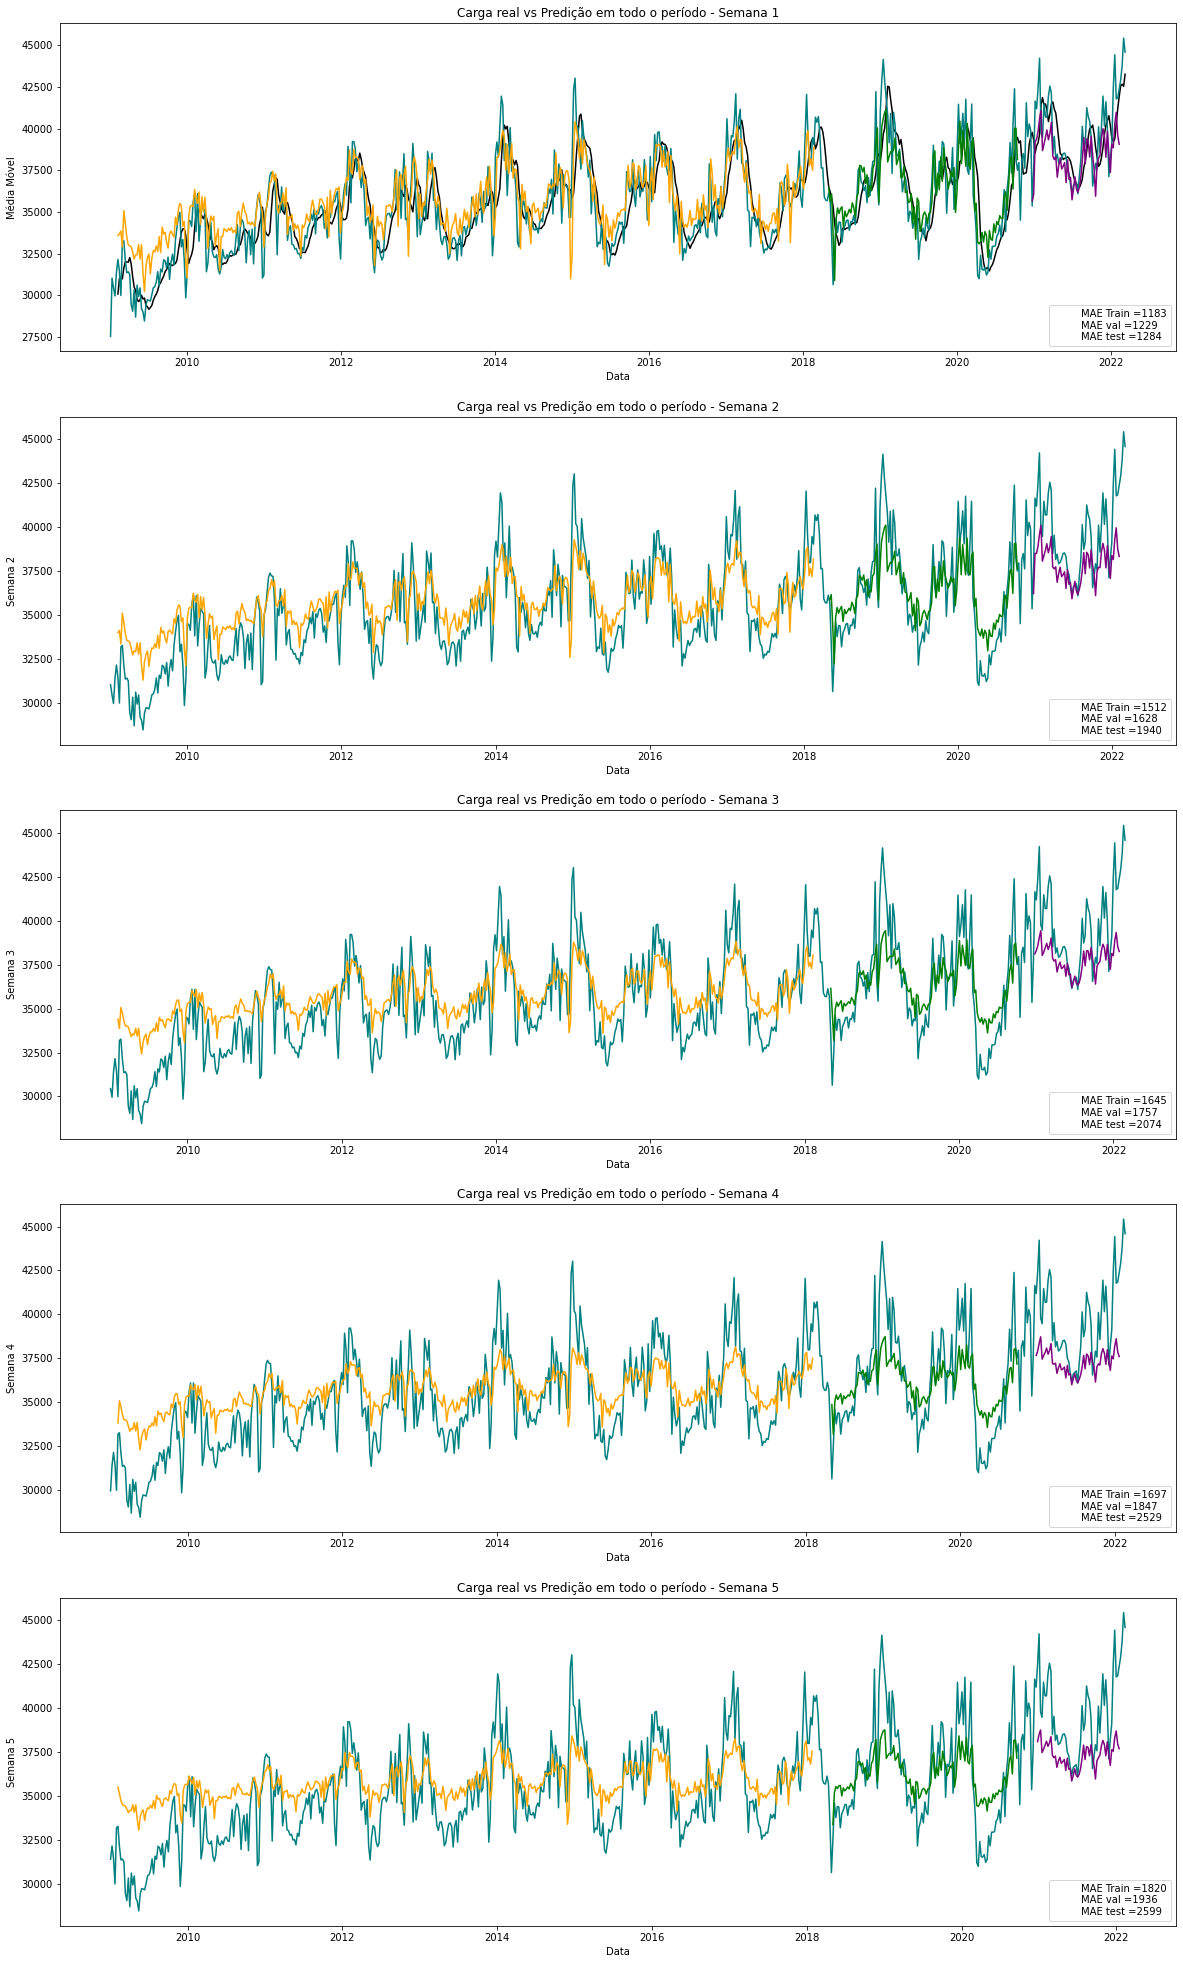

In [107]:
plot_pred(pred_list=pred_list, date_list=date_list, df_target=df_target, baseline=True)

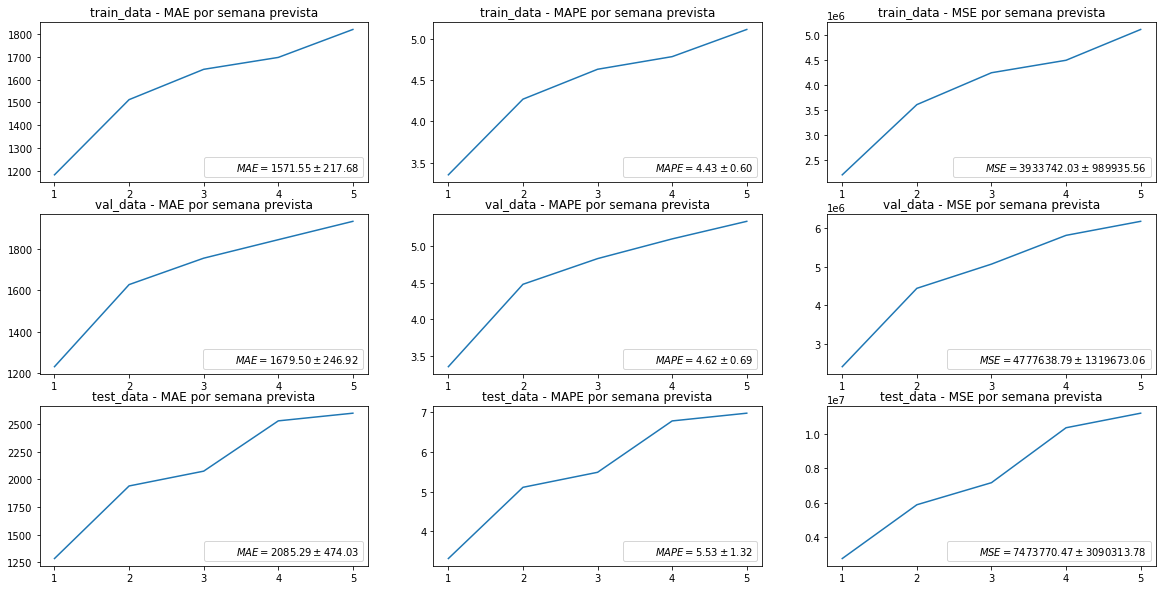

In [86]:
def metrics_semana(df_target, pred_list,date_list):
    name_dict = {'0':'train_data',
                '1':'val_data',
                '2': 'test_data'}

    fig, ax = plt.subplots(figsize=(20,10),ncols=3,nrows=3)

    for [i,df_loop,data_week] in zip([0,1,2],pred_list, date_list):

        mae_list = []
        mape_list = []
        mse_list = []

        for x in range(0,5):
            #print(f"MAE train_pred Semana {i+1}:  {mean_absolute_error(train_pred[:,i], df_target[5 : int(len(df_target)*0.7)-4].iloc[:,i])}")
            mae_list.append(mean_absolute_error(df_loop[:,x], 
                                                df_target[f'Semana {x+1}'].loc[np.array(data_week.index)]))
        for x in range(0,5):
            #print(f"MAPE train_pred Semana {i+1}: {mean_absolute_percentage_error(train_pred[:,i], df_target[5 : int(len(df_target)*0.7)-4].iloc[:,i])*100}")
            mape_list.append(mean_absolute_percentage_error(df_loop[:,x], 
                                                            df_target[f'Semana {x+1}'].loc[np.array(data_week.index)])*100)
        for x in range(0,5):
            #print(f"MSE train_pred Semeana {i+1}: {mean_squared_error(train_pred[:,i], df_target[5 : int(len(df_target)*0.7)-4].iloc[:,i])}")                
            mse_list.append(mean_squared_error(df_loop[:,x], df_target[f'Semana {x+1}'].loc[np.array(data_week.index)]))
        

        # rectangle to print the metrics mean and std over it 
        extra = plt.Rectangle((0, 0), 0, 0, fc="none", fill=False, ec='none', linewidth=0)
        # plot MAE by week
        sns.lineplot(x=range(1,6),y=mae_list, ax=ax[i,0])
        ax[i,0].set_title(f'{name_dict[str(i)]} - MAE por semana prevista')
        ax[i,0].set_xticks([1,2,3,4,5])
        scores = (r'$MAE={:.2f} \pm {:.2f}$').format(np.mean(mae_list),np.std(mae_list))
        ax[i,0].legend([extra], [scores], loc='lower right')
        # plot mape by week
        sns.lineplot(x=range(1,6),y=mape_list, ax=ax[i,1])
        ax[i,1].set_title(f'{name_dict[str(i)]} - MAPE por semana prevista')
        ax[i,1].set_xticks([1,2,3,4,5])
        scores = (r'$MAPE={:.2f} \pm {:.2f}$').format(np.mean(mape_list),np.std(mape_list))
        ax[i,1].legend([extra], [scores], loc='lower right')
        # plot MSE by week
        sns.lineplot(x=range(1,6),y=mse_list, ax=ax[i,2])
        ax[i,2].set_title(f'{name_dict[str(i)]} - MSE por semana prevista')
        ax[i,2].set_xticks([1,2,3,4,5])
        scores = (r'$MSE={:.2f} \pm {:.2f}$').format(np.mean(mse_list),np.std(mse_list))
        ax[i,2].legend([extra], [scores], loc='lower right')

    plt.show()


metrics_semana(df_target, pred_list,date_list)

# metrics_df = pd.DataFrame({'MAE': mae_list, 'MAPE':mape_list, 'MSE': mse_list})
# metrics_df.index = ['Semana 1','Semana 2','Semana 3','Semana 4','Semana 5']
# metrics_df

# Residual Analysis

In [87]:
def plot_res(df_target,pred_list, date_list):
    # variation from one week to the next
    res_baseline = df_target['Resíduo'] #- df_target['Resíduo'].mean())/df_target['Resíduo'].max()
    # prediction residues
    colors = ['orange', 'green', 'purple']


    fig, ax =plt.subplots(figsize=(20,8))
    # diferença normalizada entre semanas consecutivas
    #sns.lineplot(y=res_baseline, x=df_target['Data'], ax=ax)

    for pred, date, color in zip(pred_list,date_list,colors):
        
        res_pred = pred[:,0] - df_target[f'Semana 1'].loc[np.array(date.index)]
        sns.lineplot(y=res_pred, x=df_target['Data'], ax=ax, color= color)

    ax.set_title("Resíduo - Semana 1")
    ax.legend('')
    plt.show()

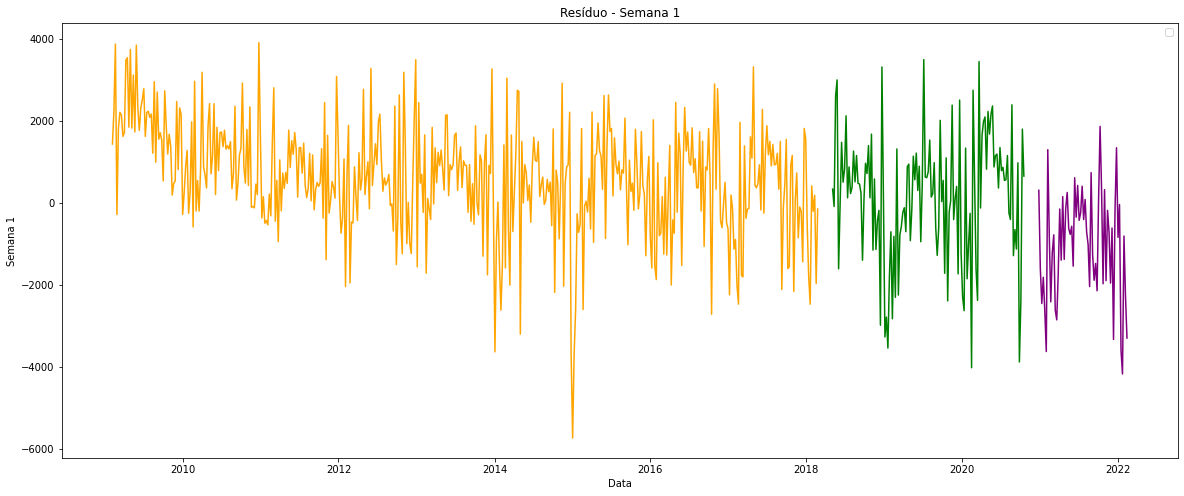

In [89]:
plot_res(df_target,pred_list, date_list)